### Model Creation

In [1]:
import pandas as pd

In [19]:
df = pd.read_csv("cleaned_data.csv")

In [20]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,8,60,1,151,67.0,120,80,2,2,0,0,0,0


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [22]:
X=df[['age','height','ap_hi','ap_lo']]

In [23]:
y=df['weight']

In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [25]:
X_train

,age,height,ap_hi,ap_lo
40704,55,155,130,90
60054,57,162,130,90
27311,49,163,120,80
36836,47,181,135,90
17802,43,180,120,80
...,...,...,...,...
54343,64,178,140,90
38158,52,165,120,80
860,45,170,110,70
15795,55,164,120,80


In [26]:
X_test

,age,height,ap_hi,ap_lo
24878,51,178,120,80
61495,44,166,120,80
24203,50,168,120,70
28056,52,163,130,90
38822,47,160,120,80
...,...,...,...,...
27058,39,165,120,80
60591,61,153,140,90
16688,42,158,120,80
31148,55,162,110,70


In [27]:
from sklearn.metrics import r2_score

In [28]:
model = LinearRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [29]:
print("Train R2 Score:", r2_score(y_train, y_train_pred)) 
print("Test R2 Score :", r2_score(y_test, y_test_pred))

Train R2 Score: 0.157284784668288
Test R2 Score : 0.14235481373369008


In [30]:
print("Coefficients:",model.coef_)

Coefficients: [0.08071855 0.51085281 0.14418073 0.13721886]


In [31]:
print("Intercept:",model.intercept_)

Intercept: -44.629565885344206


### Multiple Linear Regression

In [32]:
import numpy as np

In [33]:
# Convert to NumPy arrays 
X = X.values 
y = y.values

In [34]:
m, n = X.shape

In [35]:
weights = np.zeros(n)
bias = 0

In [36]:
learning_rate=0.0000001
epochs=50000
loss_history = []

In [37]:
for epoch in range(epochs):

    y_pred = np.dot(X, weights) + bias

    error = y_pred - y

    loss = np.mean(error ** 2)
    loss_history.append(loss)

    dw = (2 / m) * np.dot(X.T, error)
    db = (2 / m) * np.sum(error)

    weights -= learning_rate * dw
    bias -= learning_rate * db

    if epoch % 1000 == 0:
        print(f"Epoch {epoch} Loss = {loss:.4f}")

Epoch 0 Loss = 5478.6888
Epoch 1000 Loss = 127.9805
Epoch 2000 Loss = 127.9051
Epoch 3000 Loss = 127.8338
Epoch 4000 Loss = 127.7664
Epoch 5000 Loss = 127.7027
Epoch 6000 Loss = 127.6425
Epoch 7000 Loss = 127.5855
Epoch 8000 Loss = 127.5317
Epoch 9000 Loss = 127.4807
Epoch 10000 Loss = 127.4325
Epoch 11000 Loss = 127.3869
Epoch 12000 Loss = 127.3437
Epoch 13000 Loss = 127.3029
Epoch 14000 Loss = 127.2642
Epoch 15000 Loss = 127.2276
Epoch 16000 Loss = 127.1929
Epoch 17000 Loss = 127.1600
Epoch 18000 Loss = 127.1288
Epoch 19000 Loss = 127.0993
Epoch 20000 Loss = 127.0713
Epoch 21000 Loss = 127.0448
Epoch 22000 Loss = 127.0196
Epoch 23000 Loss = 126.9958
Epoch 24000 Loss = 126.9731
Epoch 25000 Loss = 126.9516
Epoch 26000 Loss = 126.9312
Epoch 27000 Loss = 126.9118
Epoch 28000 Loss = 126.8934
Epoch 29000 Loss = 126.8759
Epoch 30000 Loss = 126.8593
Epoch 31000 Loss = 126.8435
Epoch 32000 Loss = 126.8284
Epoch 33000 Loss = 126.8141
Epoch 34000 Loss = 126.8005
Epoch 35000 Loss = 126.7875
Epoc

In [44]:
print("\nWeights:")
print(weights)


Weights:
[0.04437168 0.28267473 0.13231627 0.09296338]


In [45]:
print("\nBias:")
print(bias)


Bias:
0.0009029456094693172


In [46]:
print("\nSklearn Coefficients:",model.coef_) 


Sklearn Coefficients: [0.08071855 0.51085281 0.14418073 0.13721886]


In [47]:
import matplotlib.pyplot as plt 

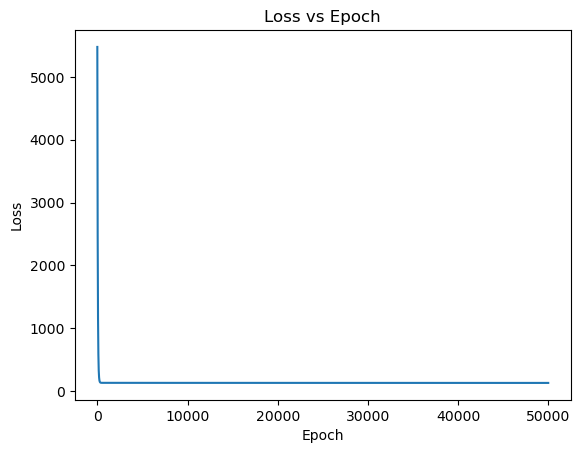

In [48]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.show()